## Setup — Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# ── Load Datasets ─────────────────────────────────────────────────
customers  = pd.read_excel("F:\Ahmed\AI & Data Science\Python\data\customers.xlsx")
products   = pd.read_excel("F:\Ahmed\AI & Data Science\Python\data\products.xlsx")
reviews    = pd.read_excel("F:\Ahmed\AI & Data Science\Python\data\customer_reviews.xlsx")
engagement = pd.read_excel("F:\Ahmed\AI & Data Science\Python\data\engagement_data.xlsx")
geography  = pd.read_excel("F:\Ahmed\AI & Data Science\Python\data\geography.xlsx")
journey    = pd.read_excel("F:\Ahmed\AI & Data Science\Python\data\customer_journey.xlsx")

# ── Clean & Prepare ──────────────────────────────────────────────
# Parse Views and Clicks from combined column (remove malformed rows first)
engagement = engagement[engagement['ViewsClickCombined'].str.match(r'^\d+-\d+$', na=False)].copy()
engagement['Views']  = engagement['ViewsClickCombined'].str.split('-').str[0].astype(int)
engagement['Clicks'] = engagement['ViewsClickCombined'].str.split('-').str[1].astype(int)
engagement.drop('ViewsClickCombined', axis=1, inplace=True)

# Standardize ContentType case
engagement['ContentType'] = engagement['ContentType'].str.strip().str.capitalize()

# Journey: fix Stage case, drop duplicates, fill Duration NaN
journey['Stage'] = journey['Stage'].str.lower().str.strip()
journey.drop_duplicates(keep='first', inplace=True)
journey['VisitDate'] = pd.to_datetime(journey['VisitDate'], errors='coerce')
journey['Duration']  = pd.to_numeric(journey['Duration'], errors='coerce')
journey['Duration']  = journey.groupby('VisitDate')['Duration'].transform(lambda x: x.fillna(x.mean()))
journey['Duration'].fillna(journey['Duration'].mean(), inplace=True)

# Merge customers with geography
cust_geo = pd.merge(customers, geography, how='left', left_on='GeographyID', right_on='ID').drop('ID', axis=1)

# Age Category: Young (18-35), Adult (36-55), Senior (56+)
def age_category(age):
    if age <= 35:   return 'Young'
    elif age <= 55: return 'Adult'
    else:           return 'Senior'
cust_geo['Age_Category'] = cust_geo['Age'].apply(age_category)

# Master merged tables
reviews_full  = (reviews
    .merge(cust_geo[['CustomerID','Gender','Age','Age_Category','Region','City']], on='CustomerID', how='left')
    .merge(products, on='ProductID', how='left'))

journey_full  = (journey
    .merge(cust_geo[['CustomerID','Gender','Age','Age_Category']], on='CustomerID', how='left')
    .merge(products, left_on='ProductId', right_on='ProductID', how='left'))

eng_full = engagement.merge(products, on='ProductID', how='left')

# Engagement score per customer (avg Likes per customer from engagement)
cust_eng = (engagement.merge(journey[['CustomerID','ProductId']].rename(columns={'ProductId':'ProductID'}),
                              on='ProductID', how='left')
             .groupby('CustomerID')['Likes'].mean().reset_index()
             .rename(columns={'Likes':'Engagement_Score'}))
cust_geo = cust_geo.merge(cust_eng, on='CustomerID', how='left')
cust_geo['Engagement_Score'] = cust_geo['Engagement_Score'].fillna(cust_geo['Engagement_Score'].mean())

# Purchase value from journey (purchases × product price)
purchases_df = journey_full[journey_full['Action']=='Purchase'][['CustomerID','Price']].copy()
cust_purchase = purchases_df.groupby('CustomerID')['Price'].sum().reset_index().rename(columns={'Price':'Purchase_Value'})
cust_geo = cust_geo.merge(cust_purchase, on='CustomerID', how='left')
cust_geo['Purchase_Value'] = cust_geo['Purchase_Value'].fillna(0)

print("All datasets loaded and prepared.")
print(f"Customers: {len(customers)} | Products: {len(products)} | Reviews: {len(reviews):,}")
print(f"Engagement: {len(engagement):,} | Journey: {len(journey):,}")

All datasets loaded and prepared.
Customers: 100 | Products: 20 | Reviews: 1,363
Engagement: 4,621 | Journey: 3,932


---## Customer Analysis

### Q1. Total kitne unique customers hain?

In [2]:
total_unique = customers['CustomerID'].nunique()
print(f"Total Unique Customers: {total_unique}")

Total Unique Customers: 100


### Q2. Age category (Young, Adult, Senior) ke hisaab se customers ki distribution

Age_Category
Young     37
Adult     42
Senior    21
Name: count, dtype: int64


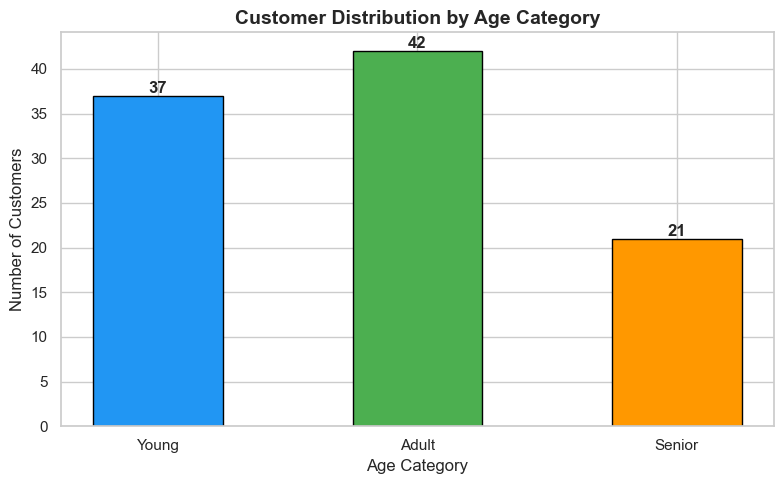

In [3]:
age_dist = cust_geo['Age_Category'].value_counts().reindex(['Young','Adult','Senior'])
print(age_dist)

plt.figure(figsize=(8, 5))
colors = ['#2196F3','#4CAF50','#FF9800']
bars = plt.bar(age_dist.index, age_dist.values, color=colors, edgecolor='black', width=0.5)
for bar, v in zip(bars, age_dist.values):
    plt.text(bar.get_x()+bar.get_width()/2, v+0.3, str(v),
             ha='center', fontweight='bold', fontsize=12)
plt.title('Customer Distribution by Age Category', fontsize=14, fontweight='bold')
plt.xlabel('Age Category')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

### Q3. Gender ke hisaab se total customers kitne hain?

Gender
Female    54
Male      46
Name: count, dtype: int64


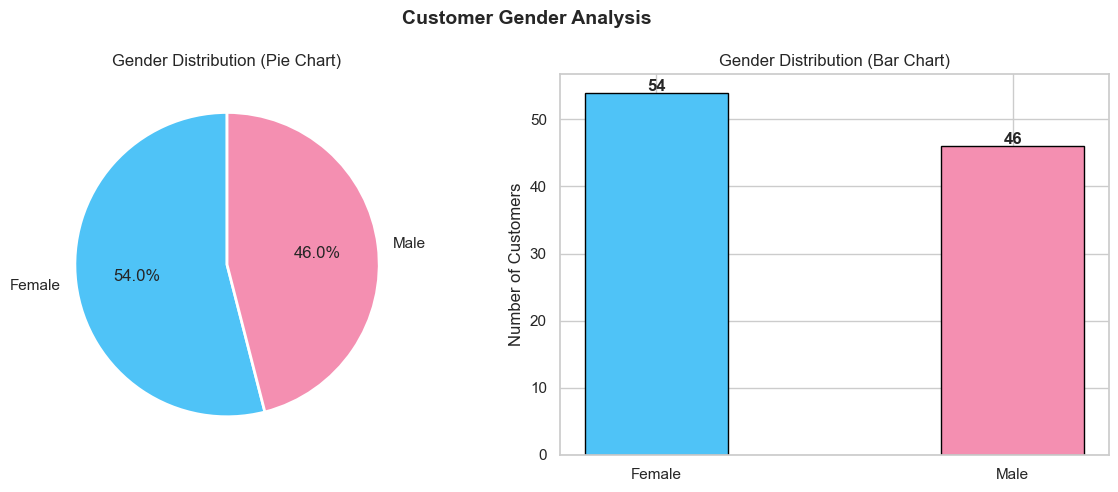

In [4]:
gender_counts = customers['Gender'].value_counts()
print(gender_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(gender_counts.values, labels=gender_counts.index,
            autopct='%1.1f%%', colors=['#4FC3F7','#F48FB1'],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Gender Distribution (Pie Chart)')

bars = axes[1].bar(gender_counts.index, gender_counts.values,
                   color=['#4FC3F7','#F48FB1'], edgecolor='black', width=0.4)
for bar, v in zip(bars, gender_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.3, str(v),
                 ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Gender Distribution (Bar Chart)')
axes[1].set_ylabel('Number of Customers')

plt.suptitle('Customer Gender Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Q4. Har age category ki average rating calculate karein

Age_Category
Young     3.68
Adult     3.70
Senior    3.66
Name: Rating, dtype: float64


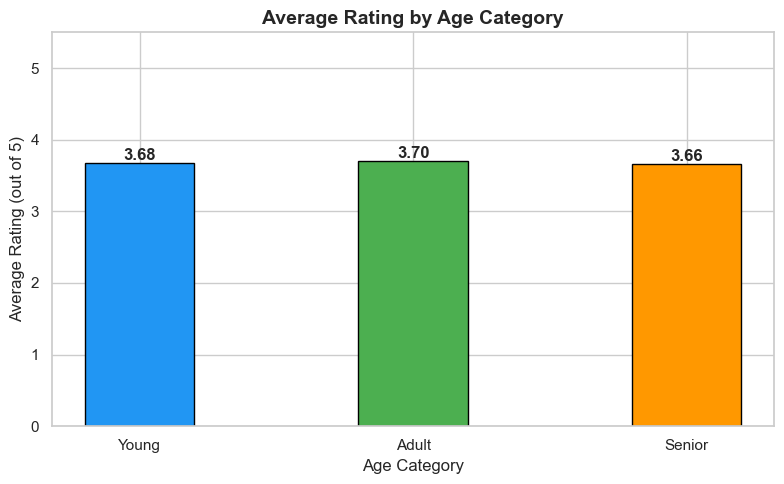

In [5]:
avg_rating_age = (reviews_full.groupby('Age_Category')['Rating']
                  .mean().reindex(['Young','Adult','Senior']).round(2))
print(avg_rating_age)

plt.figure(figsize=(8, 5))
bars = plt.bar(avg_rating_age.index, avg_rating_age.values,
               color=['#2196F3','#4CAF50','#FF9800'], edgecolor='black', width=0.4)
for bar, v in zip(bars, avg_rating_age.values):
    plt.text(bar.get_x()+bar.get_width()/2, v+0.04, f'{v:.2f}',
             ha='center', fontweight='bold', fontsize=12)
plt.title('Average Rating by Age Category', fontsize=14, fontweight='bold')
plt.xlabel('Age Category')
plt.ylabel('Average Rating (out of 5)')
plt.ylim(0, 5.5)
plt.tight_layout()
plt.show()

### Q5. Har gender ki average purchase value calculate karein

Gender
Female    439.78
Male      426.45
Name: Purchase_Value, dtype: float64


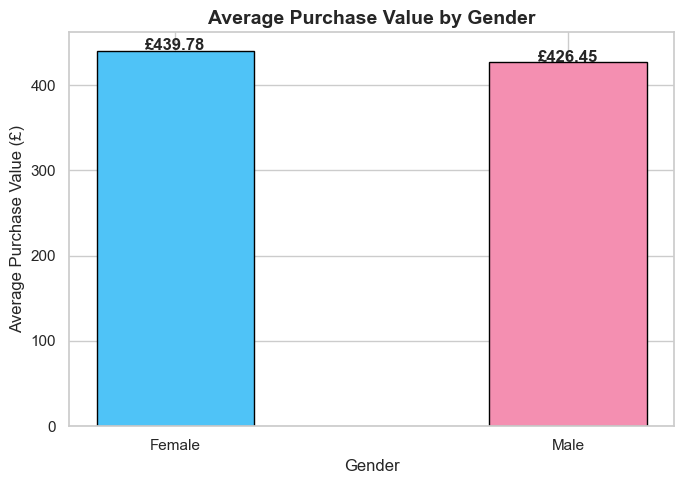

In [6]:
avg_purchase_gender = cust_geo.groupby('Gender')['Purchase_Value'].mean().round(2)
print(avg_purchase_gender)

plt.figure(figsize=(7, 5))
bars = plt.bar(avg_purchase_gender.index, avg_purchase_gender.values,
               color=['#4FC3F7','#F48FB1'], edgecolor='black', width=0.4)
for bar, v in zip(bars, avg_purchase_gender.values):
    plt.text(bar.get_x()+bar.get_width()/2, v+1, f'£{v:.2f}',
             ha='center', fontweight='bold', fontsize=12)
plt.title('Average Purchase Value by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Average Purchase Value (£)')
plt.tight_layout()
plt.show()

### Q6. Kis country mein sabse zyada customers hain?

Region
Spain          18
Italy          12
Germany        11
Austria        10
UK             10
Netherlands     9
Belgium         9
Sweden          8
Switzerland     8
France          5
Name: count, dtype: int64

Sabse zyada customers: Spain (18 customers)


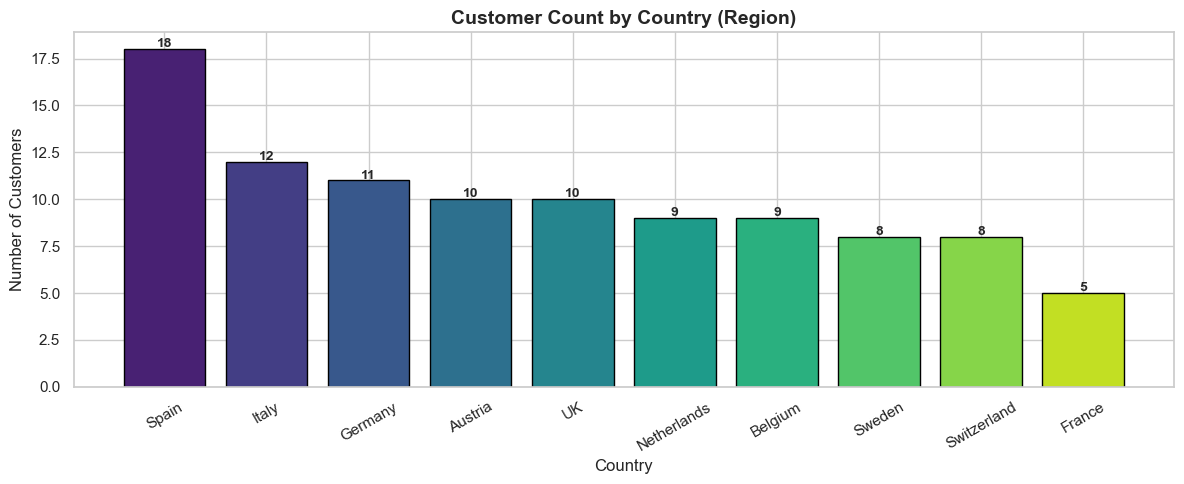

In [7]:
country_counts = cust_geo['Region'].value_counts()
print(country_counts)
print(f"\nSabse zyada customers: {country_counts.idxmax()} ({country_counts.max()} customers)")

plt.figure(figsize=(12, 5))
bars = plt.bar(country_counts.index, country_counts.values,
               color=sns.color_palette('viridis', len(country_counts)), edgecolor='black')
for bar, v in zip(bars, country_counts.values):
    plt.text(bar.get_x()+bar.get_width()/2, v+0.1, str(v),
             ha='center', fontweight='bold', fontsize=10)
plt.title('Customer Count by Country (Region)', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Q7. Har country ki average review rating calculate karein

Region
Spain          3.77
France         3.75
Germany        3.74
UK             3.72
Sweden         3.69
Netherlands    3.69
Italy          3.68
Austria        3.65
Belgium        3.58
Switzerland    3.49
Name: Rating, dtype: float64


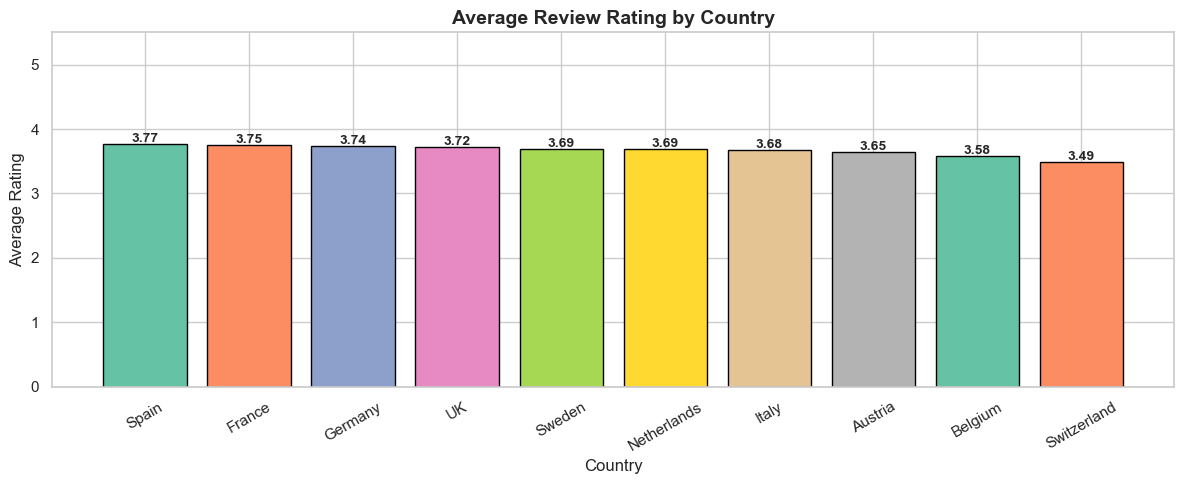

In [8]:
avg_rating_country = (reviews_full.groupby('Region')['Rating']
                      .mean().sort_values(ascending=False).round(2))
print(avg_rating_country)

plt.figure(figsize=(12, 5))
bars = plt.bar(avg_rating_country.index, avg_rating_country.values,
               color=sns.color_palette('Set2', len(avg_rating_country)), edgecolor='black')
for bar, v in zip(bars, avg_rating_country.values):
    plt.text(bar.get_x()+bar.get_width()/2, v+0.03, f'{v:.2f}',
             ha='center', fontweight='bold', fontsize=10)
plt.title('Average Review Rating by Country', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Average Rating')
plt.ylim(0, 5.5)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Q8. Har country ka average engagement score nikaalein

Region
Switzerland    115.19
Germany        114.93
Spain          114.87
France         114.51
Italy          114.37
Austria        114.28
Netherlands    114.23
Belgium        113.81
UK             113.75
Sweden         112.75
Name: Engagement_Score, dtype: float64


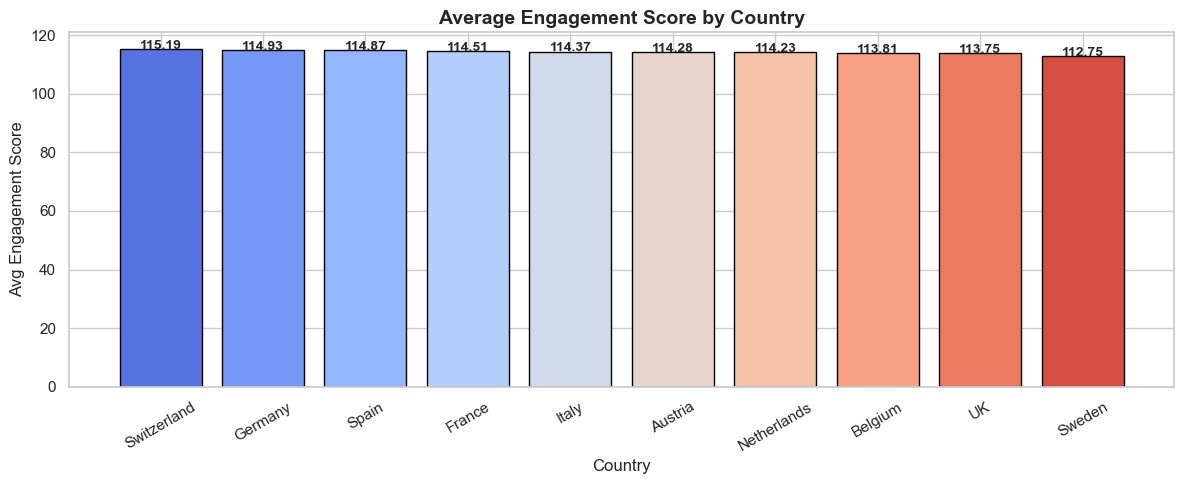

In [9]:
avg_eng_country = (cust_geo.groupby('Region')['Engagement_Score']
                   .mean().sort_values(ascending=False).round(2))
print(avg_eng_country)

plt.figure(figsize=(12, 5))
bars = plt.bar(avg_eng_country.index, avg_eng_country.values,
               color=sns.color_palette('coolwarm', len(avg_eng_country)), edgecolor='black')
for bar, v in zip(bars, avg_eng_country.values):
    plt.text(bar.get_x()+bar.get_width()/2, v+0.1, f'{v:.2f}',
             ha='center', fontweight='bold', fontsize=10)
plt.title('Average Engagement Score by Country', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Avg Engagement Score')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Q9. Kis age group ki engagement sabse zyada hai?

Age_Category
Young     113.71
Adult     114.73
Senior    114.61
Name: Engagement_Score, dtype: float64

Sabse zyada engagement: Adult (114.73)


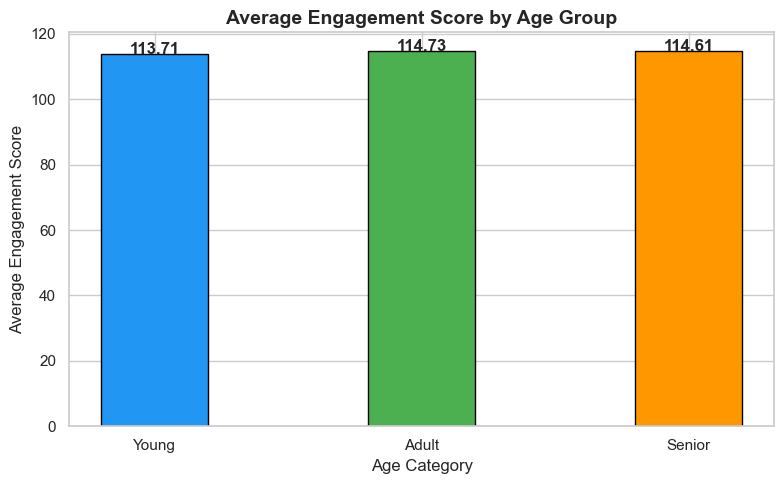

In [10]:
avg_eng_age = (cust_geo.groupby('Age_Category')['Engagement_Score']
               .mean().reindex(['Young','Adult','Senior']).round(2))
print(avg_eng_age)
print(f"\nSabse zyada engagement: {avg_eng_age.idxmax()} ({avg_eng_age.max():.2f})")

plt.figure(figsize=(8, 5))
colors = ['#2196F3','#4CAF50','#FF9800']
bars = plt.bar(avg_eng_age.index, avg_eng_age.values, color=colors, edgecolor='black', width=0.4)
for bar, v in zip(bars, avg_eng_age.values):
    plt.text(bar.get_x()+bar.get_width()/2, v+0.1, f'{v:.2f}',
             ha='center', fontweight='bold', fontsize=12)
plt.title('Average Engagement Score by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Category')
plt.ylabel('Average Engagement Score')
plt.tight_layout()
plt.show()

### Q10. Kya male aur female customers ki average ratings mein koi difference hai?

Gender
Female    3.654
Male      3.725
Name: Rating, dtype: float64
Difference: 0.071


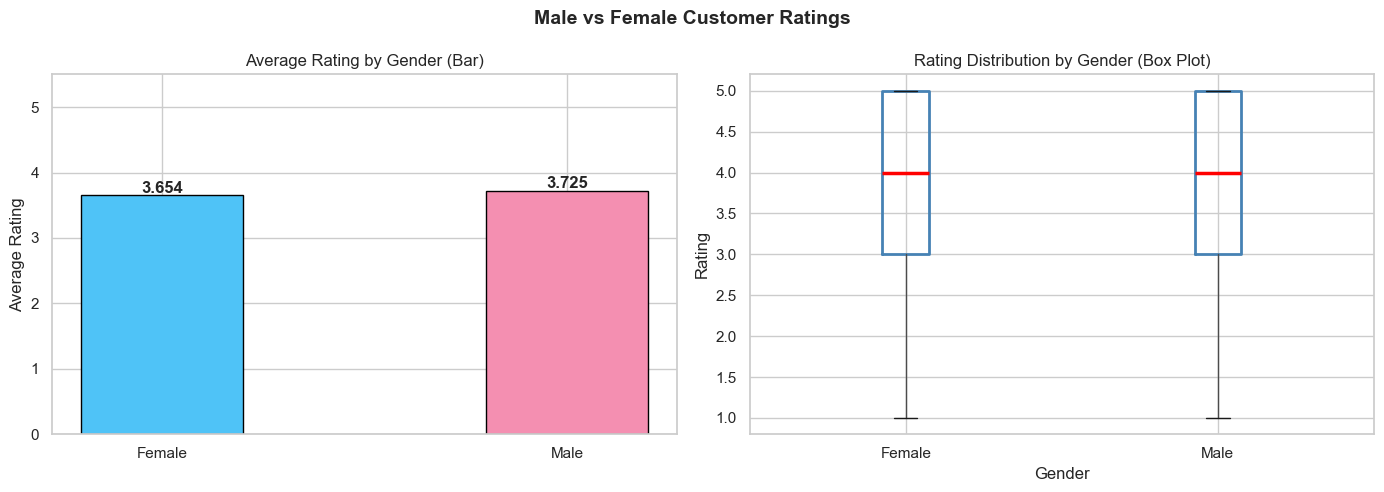


Insight: Male aur Female ki average ratings mein sirf 0.071 ka farq hai — jo negligible hai. Dono genders ka experience comparable quality level par hai.


In [11]:
avg_rating_gender = reviews_full.groupby('Gender')['Rating'].mean().round(3)
print(avg_rating_gender)
diff = abs(avg_rating_gender.max() - avg_rating_gender.min())
print(f"Difference: {diff:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
bars = axes[0].bar(avg_rating_gender.index, avg_rating_gender.values,
                   color=['#4FC3F7','#F48FB1'], edgecolor='black', width=0.4)
for bar, v in zip(bars, avg_rating_gender.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.04, f'{v:.3f}',
                 ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Average Rating by Gender (Bar)')
axes[0].set_ylabel('Average Rating')
axes[0].set_ylim(0, 5.5)

# Box plot for full distribution
reviews_full.boxplot(column='Rating', by='Gender', ax=axes[1],
                     boxprops=dict(color='steelblue', linewidth=2),
                     medianprops=dict(color='red', linewidth=2.5))
axes[1].set_title('Rating Distribution by Gender (Box Plot)')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Rating')
plt.suptitle('Male vs Female Customer Ratings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nInsight: Male aur Female ki average ratings mein sirf {diff:.3f} ka farq hai —"
      " jo negligible hai. Dono genders ka experience comparable quality level par hai.")

---## Product Analysis

### Q11. Sabse zyada purchase hone wale Top 10 products dikhayein

    ProductName  Purchase_Count
   Hockey Stick              15
 Baseball Glove              13
      Ski Boots              13
     Ice Skates              13
  Climbing Rope              12
 Cycling Helmet              12
      Surfboard              12
Fitness Tracker              11
     Golf Clubs              10
  Tennis Racket              10


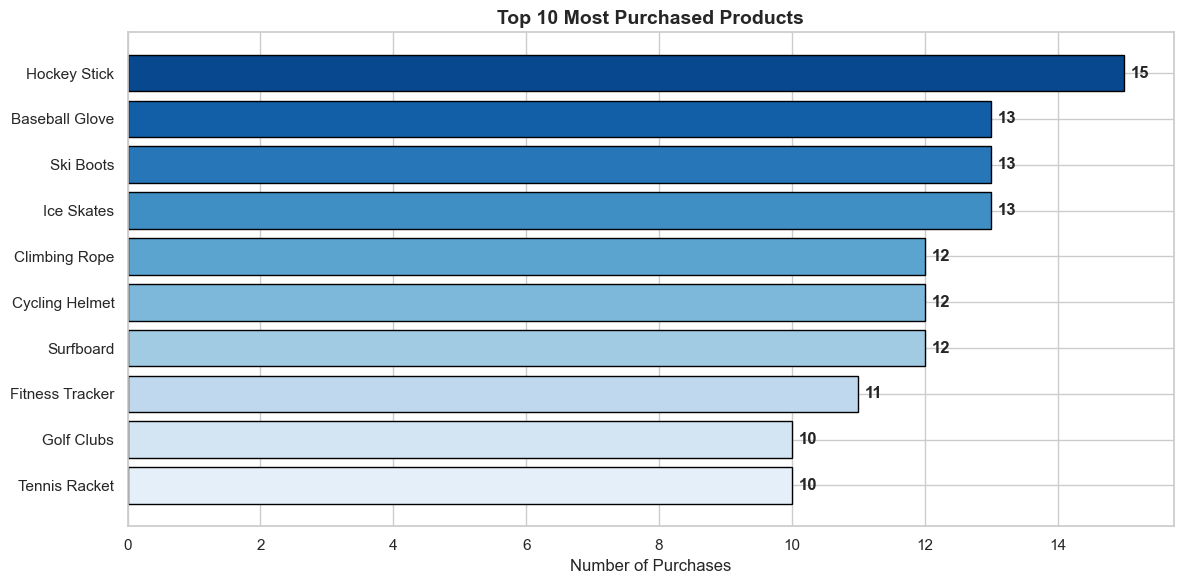

In [12]:
purchases = journey_full[journey_full['Action']=='Purchase']
top10_purchases = (purchases['ProductName'].value_counts()
                   .head(10).reset_index())
top10_purchases.columns = ['ProductName','Purchase_Count']
print(top10_purchases.to_string(index=False))

plt.figure(figsize=(12, 6))
bars = plt.barh(top10_purchases['ProductName'], top10_purchases['Purchase_Count'],
                color=sns.color_palette('Blues_r', 10), edgecolor='black')
for bar, v in zip(bars, top10_purchases['Purchase_Count']):
    plt.text(v+0.1, bar.get_y()+bar.get_height()/2, str(v),
             va='center', fontweight='bold')
plt.title('Top 10 Most Purchased Products', fontsize=14, fontweight='bold')
plt.xlabel('Number of Purchases')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Q12. Sabse zyada reviews kis product ko mile hain?

    ProductName  Review_Count
     Ice Skates            79
Fitness Tracker            76
    Soccer Ball            75
          Kayak            75
      Dumbbells            75
   Swim Goggles            73
 Baseball Glove            73
      Surfboard            72
  Tennis Racket            72
  Climbing Rope            69
      Ski Boots            67
       Yoga Mat            65
Football Helmet            64
     Golf Clubs            64
     Basketball            64
   Hockey Stick            63
  Running Shoes            63
  Boxing Gloves            59
     Volleyball            59
 Cycling Helmet            56

Sabse zyada reviews: 'Ice Skates' (79 reviews)


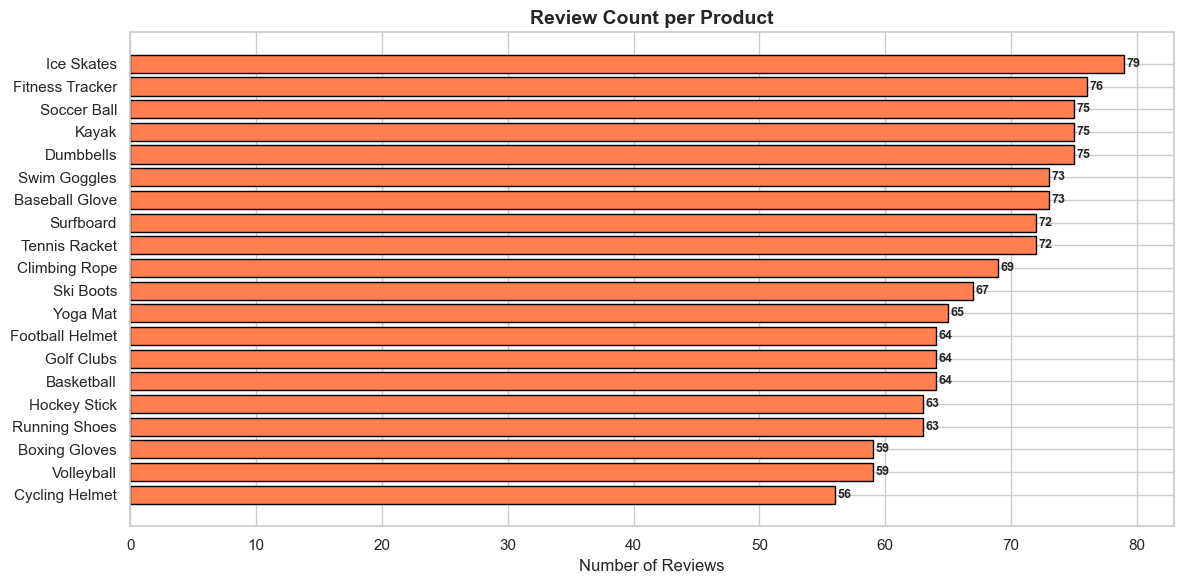

In [13]:
review_counts = (reviews_full.groupby('ProductName')['ReviewID']
                 .count().sort_values(ascending=False).reset_index())
review_counts.columns = ['ProductName','Review_Count']
print(review_counts.to_string(index=False))

most_reviewed = review_counts.iloc[0]
print(f"\nSabse zyada reviews: '{most_reviewed['ProductName']}' ({most_reviewed['Review_Count']} reviews)")

plt.figure(figsize=(12, 6))
bars = plt.barh(review_counts['ProductName'], review_counts['Review_Count'],
                color='coral', edgecolor='black')
for bar, v in zip(bars, review_counts['Review_Count']):
    plt.text(v+0.2, bar.get_y()+bar.get_height()/2, str(v),
             va='center', fontweight='bold', fontsize=9)
plt.title('Review Count per Product', fontsize=14, fontweight='bold')
plt.xlabel('Number of Reviews')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Q13. Sabse zyada engagement wale Top 10 products identify karein

  ProductName  Total_Engagement  Total_Views  Total_Clicks  Total_Likes
   Basketball            833441       676568        127290        29583
Running Shoes            831048       660923        139019        31106
Climbing Rope            800693       643901        129554        27238
   Ice Skates            792697       639254        126104        27339
 Swim Goggles            792623       637380        125861        29382
  Soccer Ball            780937       623257        127671        30009
   Golf Clubs            765436       617481        119239        28716
Tennis Racket            747447       617016        107464        22967
        Kayak            738121       592054        117854        28213
     Yoga Mat            726991       578549        118852        29590


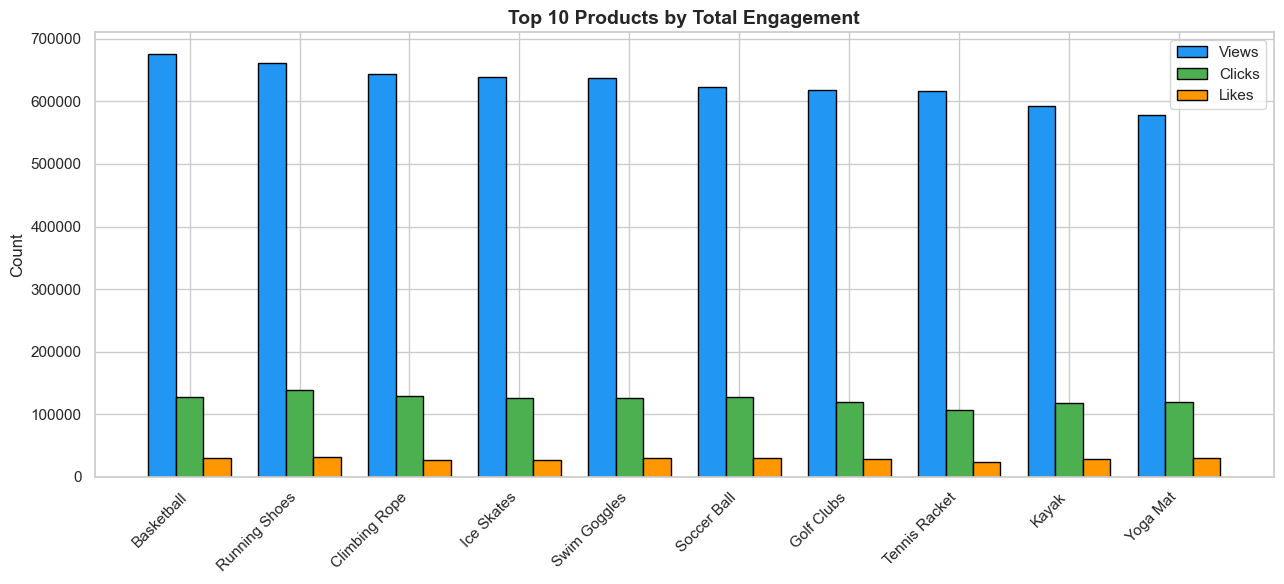

In [14]:
prod_eng = (eng_full.groupby('ProductName')
            .agg(Total_Views=('Views','sum'),
                 Total_Clicks=('Clicks','sum'),
                 Total_Likes=('Likes','sum'))
            .reset_index())
prod_eng['Total_Engagement'] = prod_eng['Total_Views'] + prod_eng['Total_Clicks'] + prod_eng['Total_Likes']
top10_eng = prod_eng.nlargest(10, 'Total_Engagement')[['ProductName','Total_Engagement','Total_Views','Total_Clicks','Total_Likes']]
print(top10_eng.to_string(index=False))

x = range(len(top10_eng))
w = 0.25
plt.figure(figsize=(13, 6))
plt.bar([i-w for i in x], top10_eng['Total_Views'],   width=w, label='Views',  color='#2196F3', edgecolor='black')
plt.bar([i   for i in x], top10_eng['Total_Clicks'],  width=w, label='Clicks', color='#4CAF50', edgecolor='black')
plt.bar([i+w for i in x], top10_eng['Total_Likes'],   width=w, label='Likes',  color='#FF9800', edgecolor='black')
plt.xticks(list(x), top10_eng['ProductName'], rotation=45, ha='right')
plt.title('Top 10 Products by Total Engagement', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

### Q14. Har product category ki average rating calculate karein

Category
Sports    3.69
Name: Rating, dtype: float64


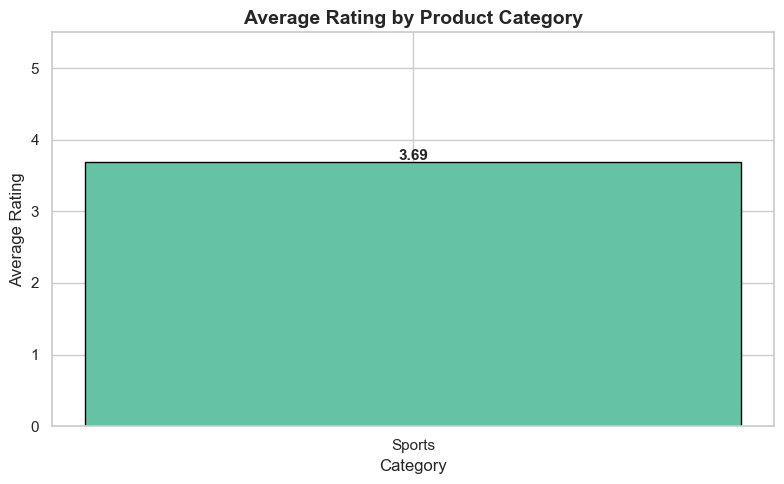

In [15]:
avg_rating_cat = (reviews_full.groupby('Category')['Rating']
                  .mean().sort_values(ascending=False).round(2))
print(avg_rating_cat)

plt.figure(figsize=(8, 5))
bars = plt.bar(avg_rating_cat.index, avg_rating_cat.values,
               color=sns.color_palette('Set2', len(avg_rating_cat)), edgecolor='black')
for bar, v in zip(bars, avg_rating_cat.values):
    plt.text(bar.get_x()+bar.get_width()/2, v+0.03, f'{v:.2f}',
             ha='center', fontweight='bold', fontsize=11)
plt.title('Average Rating by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.ylim(0, 5.5)
plt.tight_layout()
plt.show()

### Q15. Har category ki average engagement calculate karein

Category  Avg_Views  Avg_Clicks  Avg_Likes  Avg_Engagement
  Sports     2545.9       498.2      114.4          3158.5


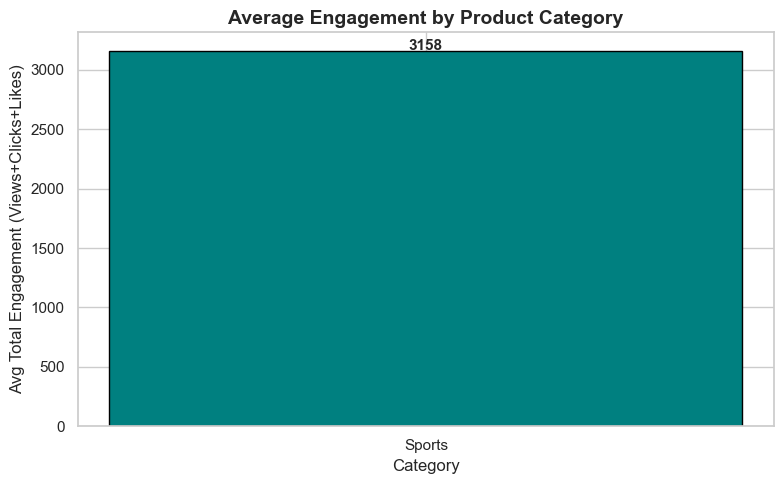

In [16]:
avg_eng_cat = (eng_full.groupby('Category')
               .agg(Avg_Views=('Views','mean'),
                    Avg_Clicks=('Clicks','mean'),
                    Avg_Likes=('Likes','mean'))
               .round(1).reset_index())
avg_eng_cat['Avg_Engagement'] = avg_eng_cat['Avg_Views'] + avg_eng_cat['Avg_Clicks'] + avg_eng_cat['Avg_Likes']
avg_eng_cat = avg_eng_cat.sort_values('Avg_Engagement', ascending=False)
print(avg_eng_cat.to_string(index=False))

plt.figure(figsize=(8, 5))
bars = plt.bar(avg_eng_cat['Category'], avg_eng_cat['Avg_Engagement'],
               color='teal', edgecolor='black')
for bar, v in zip(bars, avg_eng_cat['Avg_Engagement']):
    plt.text(bar.get_x()+bar.get_width()/2, v+5, f'{v:.0f}',
             ha='center', fontweight='bold', fontsize=11)
plt.title('Average Engagement by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Avg Total Engagement (Views+Clicks+Likes)')
plt.tight_layout()
plt.show()

### Q16. Har category ki average views aur clicks compare karein

          Avg_Views  Avg_Clicks
Category                       
Sports       2545.9       498.2


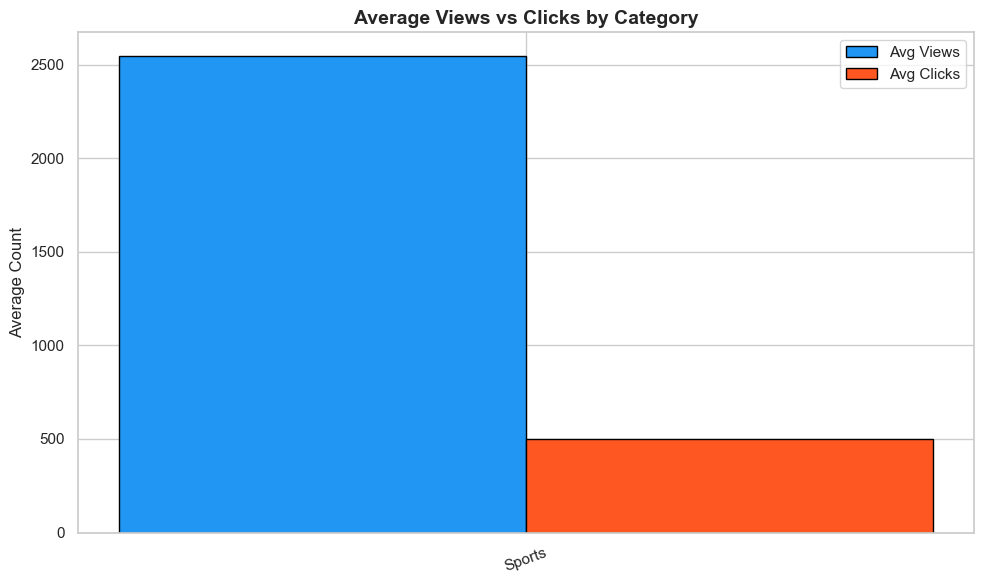

In [17]:
cat_vc = (eng_full.groupby('Category')
          .agg(Avg_Views=('Views','mean'),
               Avg_Clicks=('Clicks','mean'))
          .round(1).sort_values('Avg_Views', ascending=False))
print(cat_vc)

x = range(len(cat_vc))
w = 0.35
plt.figure(figsize=(10, 6))
plt.bar([i-w/2 for i in x], cat_vc['Avg_Views'],  width=w, label='Avg Views',
        color='#2196F3', edgecolor='black')
plt.bar([i+w/2 for i in x], cat_vc['Avg_Clicks'], width=w, label='Avg Clicks',
        color='#FF5722', edgecolor='black')
plt.xticks(list(x), cat_vc.index, rotation=20)
plt.title('Average Views vs Clicks by Category', fontsize=14, fontweight='bold')
plt.ylabel('Average Count')
plt.legend()
plt.tight_layout()
plt.show()

### Q17. Lowest rated Top 10 products kaun se hain?

  ProductName  Avg_Rating
   Golf Clubs        3.48
     Yoga Mat        3.52
Tennis Racket        3.56
Running Shoes        3.57
   Volleyball        3.58
Boxing Gloves        3.61
    Dumbbells        3.63
    Surfboard        3.65
 Hockey Stick        3.67
  Soccer Ball        3.67


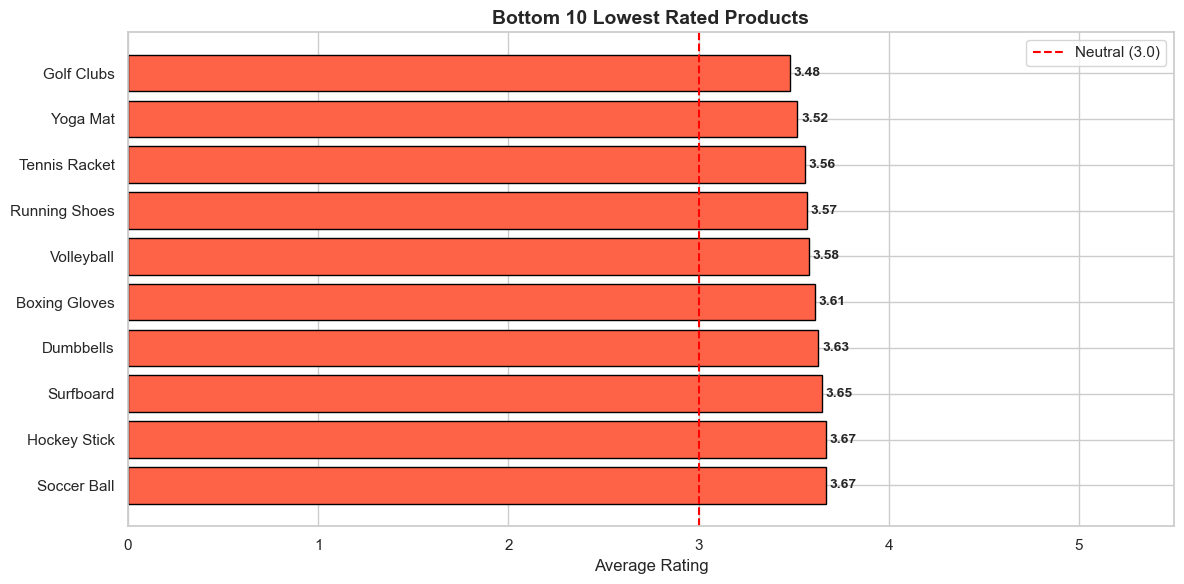

In [18]:
avg_rating_prod = (reviews_full.groupby('ProductName')['Rating']
                   .mean().round(2).reset_index())
avg_rating_prod.columns = ['ProductName','Avg_Rating']
bottom10 = avg_rating_prod.nsmallest(10, 'Avg_Rating')
print(bottom10.to_string(index=False))

plt.figure(figsize=(12, 6))
bars = plt.barh(bottom10['ProductName'], bottom10['Avg_Rating'],
                color='tomato', edgecolor='black')
plt.axvline(3.0, color='red', linestyle='--', linewidth=1.5, label='Neutral (3.0)')
for bar, v in zip(bars, bottom10['Avg_Rating']):
    plt.text(v+0.02, bar.get_y()+bar.get_height()/2, f'{v:.2f}',
             va='center', fontweight='bold', fontsize=10)
plt.title('Bottom 10 Lowest Rated Products', fontsize=14, fontweight='bold')
plt.xlabel('Average Rating')
plt.xlim(0, 5.5)
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

### Q18. Highest rated Top 10 products kaun se hain?

    ProductName  Avg_Rating
  Climbing Rope        3.91
   Swim Goggles        3.84
 Cycling Helmet        3.80
          Kayak        3.79
     Basketball        3.78
Fitness Tracker        3.78
 Baseball Glove        3.73
      Ski Boots        3.73
Football Helmet        3.70
     Ice Skates        3.70


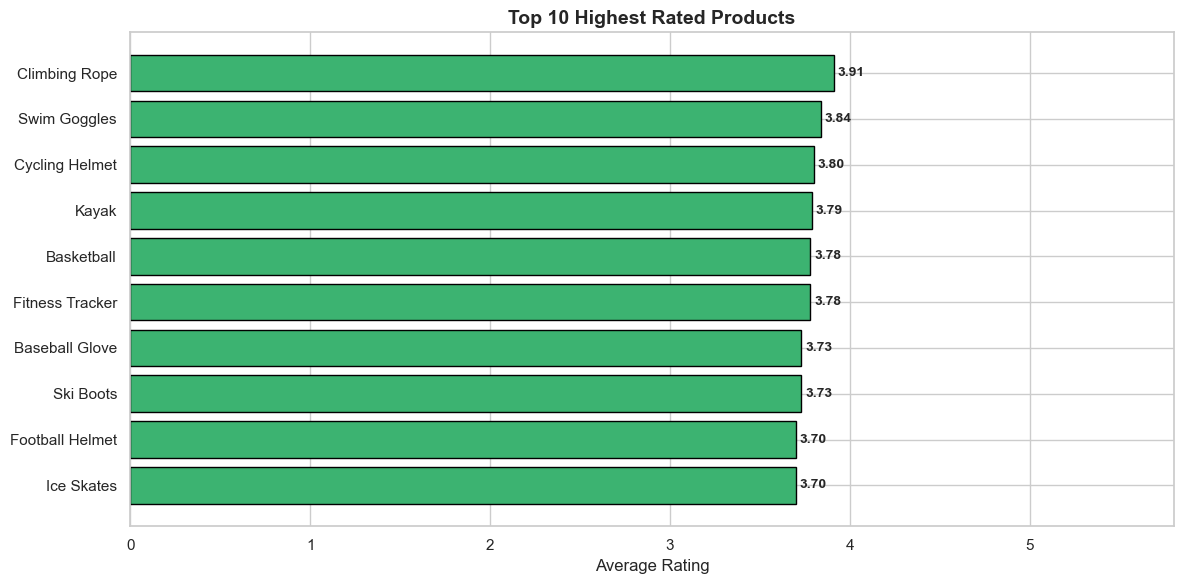

In [19]:
top10_rated = avg_rating_prod.nlargest(10, 'Avg_Rating')
print(top10_rated.to_string(index=False))

plt.figure(figsize=(12, 6))
bars = plt.barh(top10_rated['ProductName'], top10_rated['Avg_Rating'],
                color='mediumseagreen', edgecolor='black')
for bar, v in zip(bars, top10_rated['Avg_Rating']):
    plt.text(v+0.02, bar.get_y()+bar.get_height()/2, f'{v:.2f}',
             va='center', fontweight='bold', fontsize=10)
plt.title('Top 10 Highest Rated Products', fontsize=14, fontweight='bold')
plt.xlabel('Average Rating')
plt.xlim(0, 5.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Q19. Kis category mein views zyada hain lekin purchases kam hain?

          Total_Views  Purchases  View_to_Purchase_Ratio
Category                                                
Sports       11764570        198                 59118.4


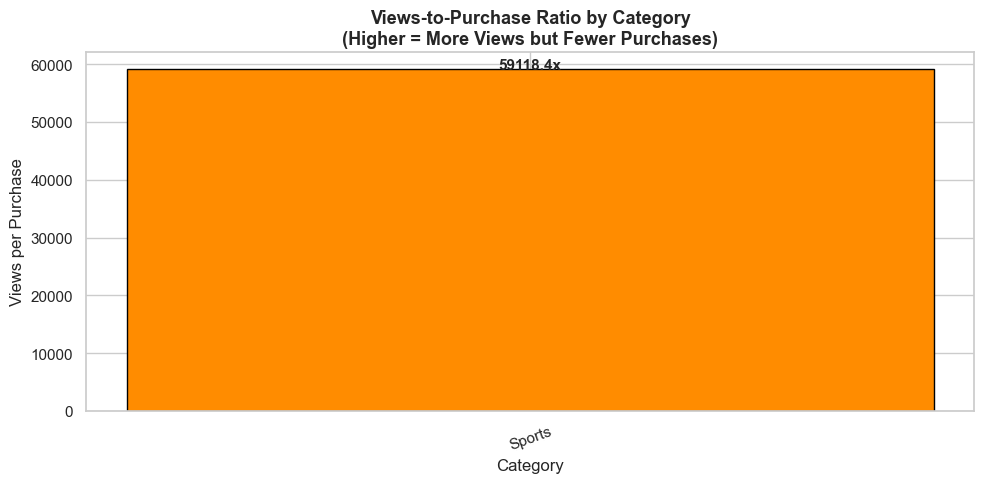


Sabse zyada views lekin kam purchases: 'Sports' category


In [20]:
cat_views = eng_full.groupby('Category')['Views'].sum()
cat_purch = journey_full[journey_full['Action']=='Purchase'].groupby('Category').size()

conv_df = pd.DataFrame({'Total_Views': cat_views, 'Purchases': cat_purch}).fillna(0)
conv_df['View_to_Purchase_Ratio'] = (conv_df['Total_Views'] / (conv_df['Purchases']+1)).round(1)
conv_df = conv_df.sort_values('View_to_Purchase_Ratio', ascending=False)
print(conv_df)

plt.figure(figsize=(10, 5))
bars = plt.bar(conv_df.index, conv_df['View_to_Purchase_Ratio'],
               color='darkorange', edgecolor='black')
for bar, v in zip(bars, conv_df['View_to_Purchase_Ratio']):
    plt.text(bar.get_x()+bar.get_width()/2, v+0.2, f'{v:.1f}x',
             ha='center', fontweight='bold', fontsize=11)
plt.title('Views-to-Purchase Ratio by Category\n(Higher = More Views but Fewer Purchases)',
          fontsize=13, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Views per Purchase')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

worst = conv_df['View_to_Purchase_Ratio'].idxmax()
print(f"\nSabse zyada views lekin kam purchases: '{worst}' category")

### Q20. Product popularity ko bar chart ke zariye visualize karein

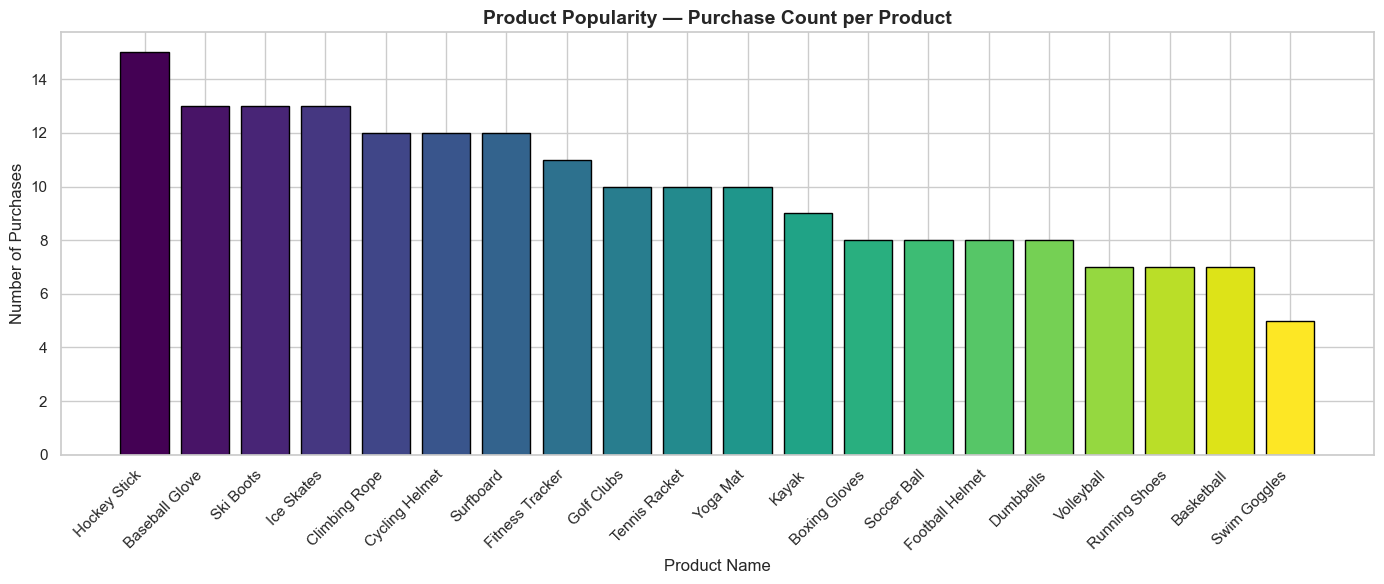

In [21]:
purchase_counts = journey_full[journey_full['Action']=='Purchase']['ProductName'].value_counts()

plt.figure(figsize=(14, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(purchase_counts)))
bars = plt.bar(purchase_counts.index, purchase_counts.values, color=colors, edgecolor='black')
plt.title('Product Popularity — Purchase Count per Product', fontsize=14, fontweight='bold')
plt.xlabel('Product Name')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---## Engagement Analysis

### Q21. Total Views, Total Clicks aur Total Likes calculate karein

Total Views  : 11,764,570
Total Clicks : 2,301,961
Total Likes  : 528,726


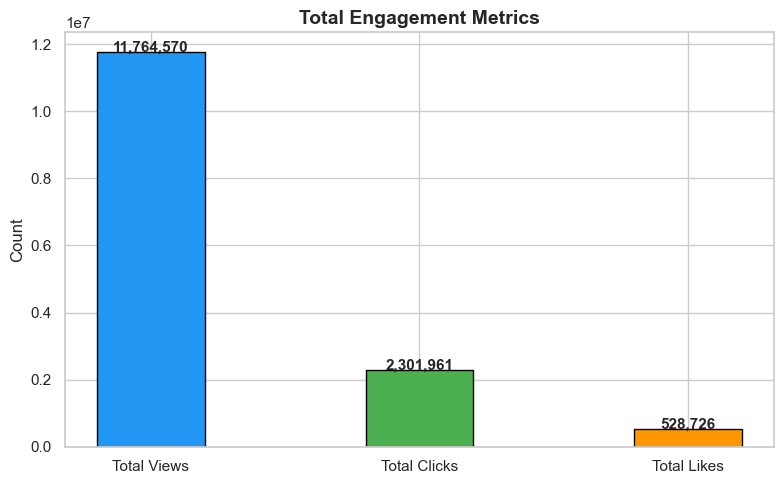

In [22]:
total_views  = engagement['Views'].sum()
total_clicks = engagement['Clicks'].sum()
total_likes  = engagement['Likes'].sum()

print(f"Total Views  : {total_views:,}")
print(f"Total Clicks : {total_clicks:,}")
print(f"Total Likes  : {total_likes:,}")

plt.figure(figsize=(8, 5))
metrics = ['Total Views','Total Clicks','Total Likes']
values  = [total_views, total_clicks, total_likes]
bars = plt.bar(metrics, values,
               color=['#2196F3','#4CAF50','#FF9800'], edgecolor='black', width=0.4)
for bar, v in zip(bars, values):
    plt.text(bar.get_x()+bar.get_width()/2, v+200, f'{v:,}',
             ha='center', fontsize=11, fontweight='bold')
plt.title('Total Engagement Metrics', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Q22. Overall Engagement Rate calculate karein

Overall Engagement Rate : 24.06%
Overall CTR (Clicks/Views): 19.57%


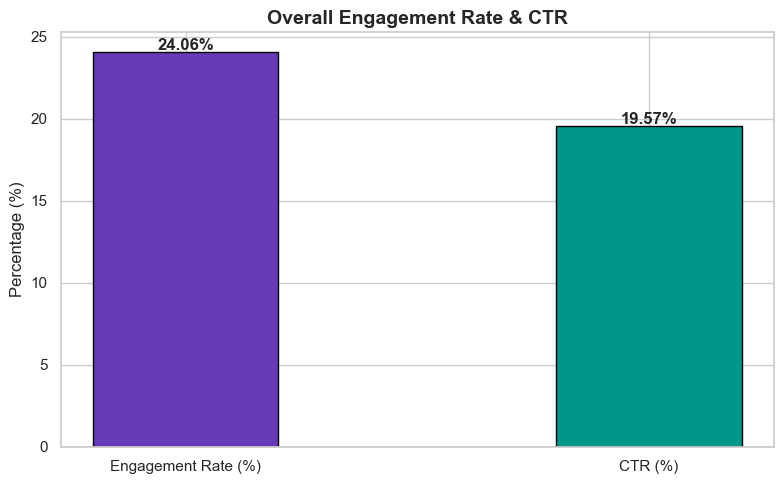

In [23]:
# Engagement Rate = (Clicks + Likes) / Views * 100
eng_rate = (total_clicks + total_likes) / total_views * 100
ctr      = total_clicks / total_views * 100

print(f"Overall Engagement Rate : {eng_rate:.2f}%")
print(f"Overall CTR (Clicks/Views): {ctr:.2f}%")

plt.figure(figsize=(8, 5))
bars = plt.bar(['Engagement Rate (%)','CTR (%)'], [eng_rate, ctr],
               color=['#673AB7','#009688'], edgecolor='black', width=0.4)
for bar, v in zip(bars, [eng_rate, ctr]):
    plt.text(bar.get_x()+bar.get_width()/2, v+0.1, f'{v:.2f}%',
             ha='center', fontweight='bold', fontsize=12)
plt.title('Overall Engagement Rate & CTR', fontsize=14, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.tight_layout()
plt.show()

### Q23. Har product ka Engagement Rate compare karein

    ProductName  Total_Views  Total_Clicks  Total_Likes  Engagement_Rate
      Surfboard       498753        104928        24622            25.97
  Running Shoes       660923        139019        31106            25.74
       Yoga Mat       578549        118852        29590            25.66
    Soccer Ball       623257        127671        30009            25.30
   Hockey Stick       578316        116785        27862            25.01
 Baseball Glove       565109        113642        27452            24.97
Football Helmet       529241        107613        23367            24.75
          Kayak       592054        117854        28213            24.67
  Boxing Gloves       571937        114522        26512            24.66
   Swim Goggles       637380        125861        29382            24.36
  Climbing Rope       643901        129554        27238            24.35
     Ice Skates       639254        126104        27339            24.00
     Golf Clubs       617481        119239        2

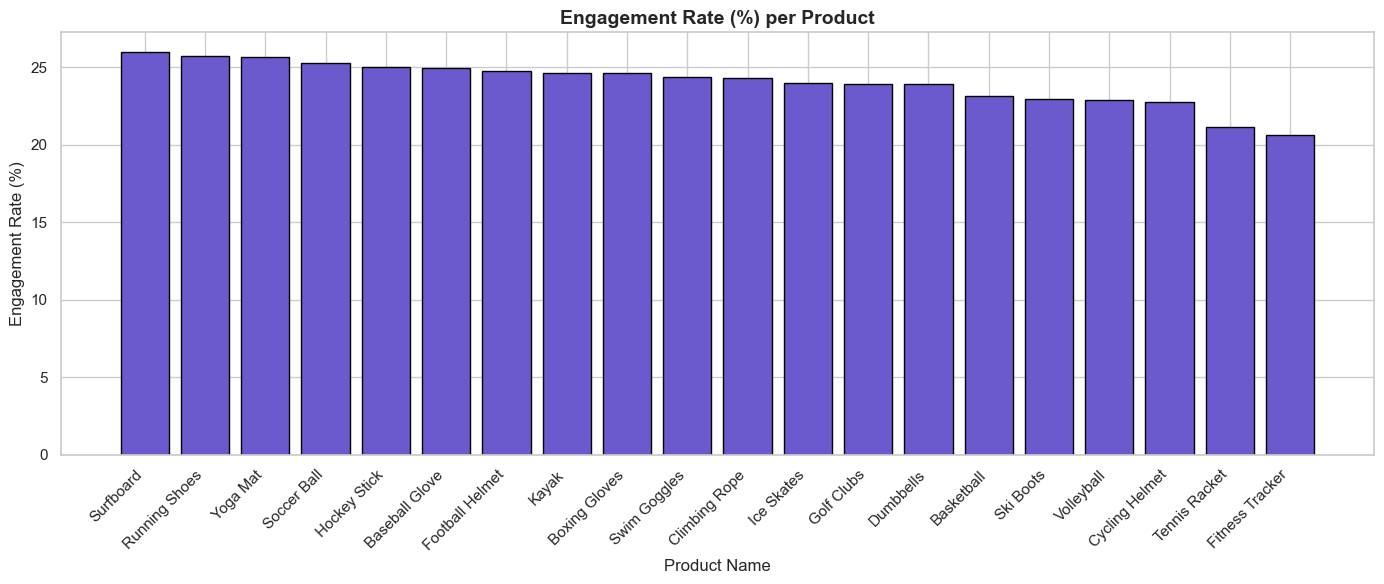

In [24]:
prod_eng['Engagement_Rate'] = ((prod_eng['Total_Clicks'] + prod_eng['Total_Likes'])
                                 / prod_eng['Total_Views'] * 100).round(2)
prod_eng_sorted = prod_eng.sort_values('Engagement_Rate', ascending=False)
print(prod_eng_sorted[['ProductName','Total_Views','Total_Clicks','Total_Likes','Engagement_Rate']].to_string(index=False))

plt.figure(figsize=(14, 6))
plt.bar(prod_eng_sorted['ProductName'], prod_eng_sorted['Engagement_Rate'],
        color='slateblue', edgecolor='black')
plt.title('Engagement Rate (%) per Product', fontsize=14, fontweight='bold')
plt.xlabel('Product Name')
plt.ylabel('Engagement Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Q24. Sabse zyada viewed aur sabse zyada clicked products identify karein

Most Viewed Product  : Basketball (676,568 views)
Most Clicked Product : Running Shoes (139,019 clicks)


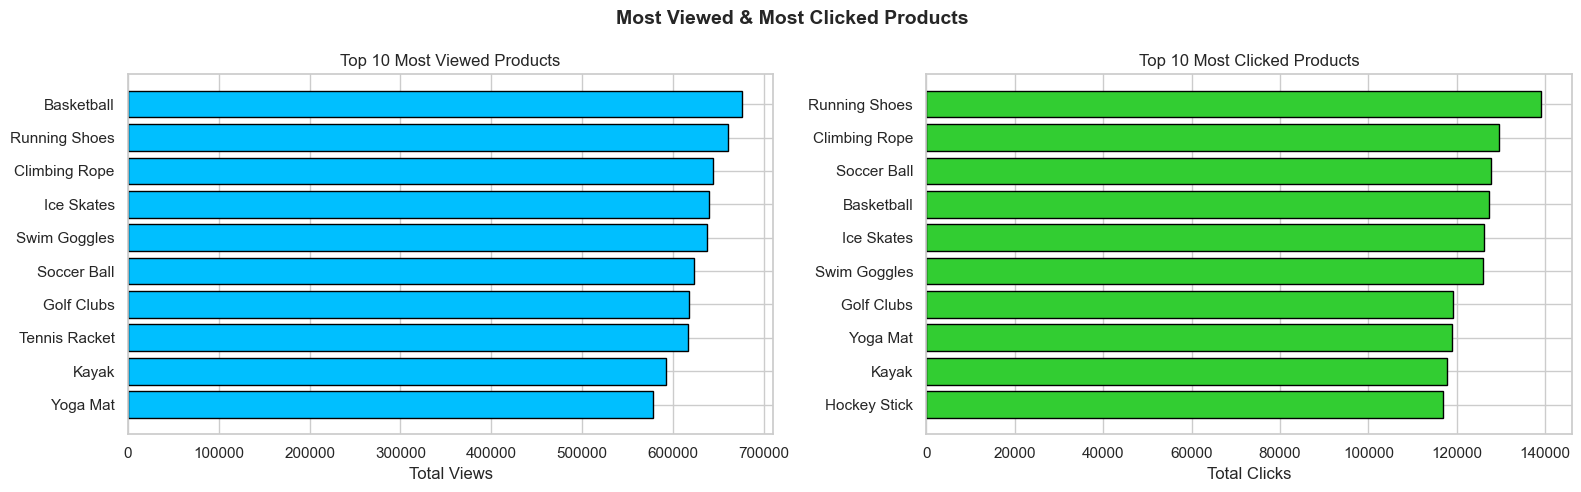

In [25]:
most_viewed  = prod_eng.loc[prod_eng['Total_Views'].idxmax()]
most_clicked = prod_eng.loc[prod_eng['Total_Clicks'].idxmax()]

print(f"Most Viewed Product  : {most_viewed['ProductName']} ({most_viewed['Total_Views']:,} views)")
print(f"Most Clicked Product : {most_clicked['ProductName']} ({most_clicked['Total_Clicks']:,} clicks)")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top10_viewed  = prod_eng.nlargest(10, 'Total_Views')
top10_clicked = prod_eng.nlargest(10, 'Total_Clicks')

axes[0].barh(top10_viewed['ProductName'], top10_viewed['Total_Views'],
             color='deepskyblue', edgecolor='black')
axes[0].set_title('Top 10 Most Viewed Products')
axes[0].set_xlabel('Total Views')
axes[0].invert_yaxis()

axes[1].barh(top10_clicked['ProductName'], top10_clicked['Total_Clicks'],
             color='limegreen', edgecolor='black')
axes[1].set_title('Top 10 Most Clicked Products')
axes[1].set_xlabel('Total Clicks')
axes[1].invert_yaxis()

plt.suptitle('Most Viewed & Most Clicked Products', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Q25. Least engaged products kaun se hain?

    ProductName  Total_Views  Total_Clicks  Total_Likes  Engagement_Rate
Fitness Tracker       505085         87073        17205            20.65
  Tennis Racket       617016        107464        22967            21.14
 Cycling Helmet       542610         99694        23685            22.74
     Volleyball       577999        107516        24961            22.92
      Ski Boots       541893        100651        23915            22.99
     Basketball       676568        127290        29583            23.19
      Dumbbells       567244        110629        25002            23.91
     Golf Clubs       617481        119239        28716            23.96
     Ice Skates       639254        126104        27339            24.00
  Climbing Rope       643901        129554        27238            24.35


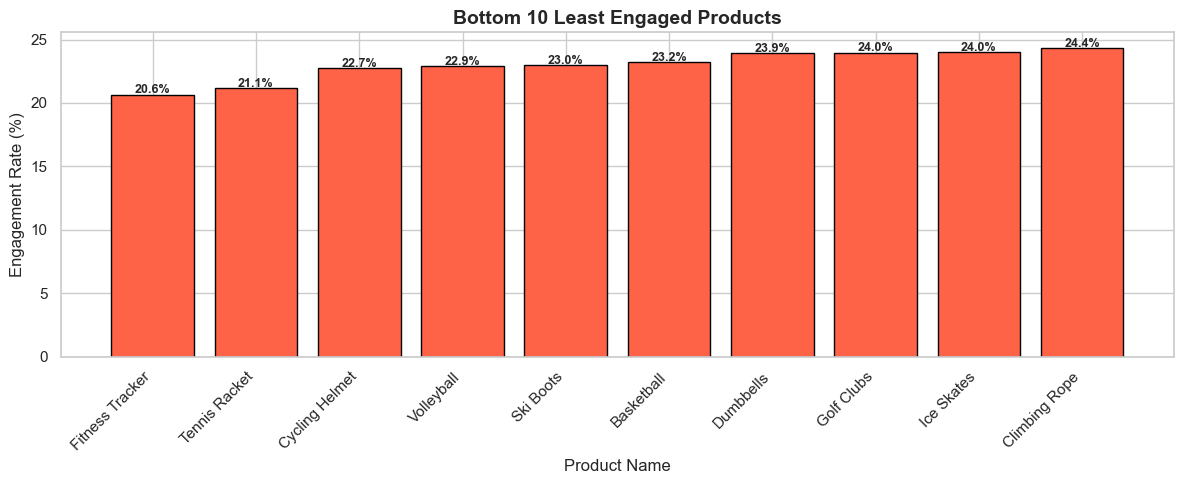

In [26]:
bottom10_eng = prod_eng.nsmallest(10, 'Engagement_Rate')[['ProductName','Total_Views','Total_Clicks','Total_Likes','Engagement_Rate']]
print(bottom10_eng.to_string(index=False))

plt.figure(figsize=(12, 5))
bars = plt.bar(bottom10_eng['ProductName'], bottom10_eng['Engagement_Rate'],
               color='tomato', edgecolor='black')
for bar, v in zip(bars, bottom10_eng['Engagement_Rate']):
    plt.text(bar.get_x()+bar.get_width()/2, v+0.1, f'{v:.1f}%',
             ha='center', fontweight='bold', fontsize=9)
plt.title('Bottom 10 Least Engaged Products', fontsize=14, fontweight='bold')
plt.xlabel('Product Name')
plt.ylabel('Engagement Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Q26. Daily ya Monthly conversion trend visualize karein

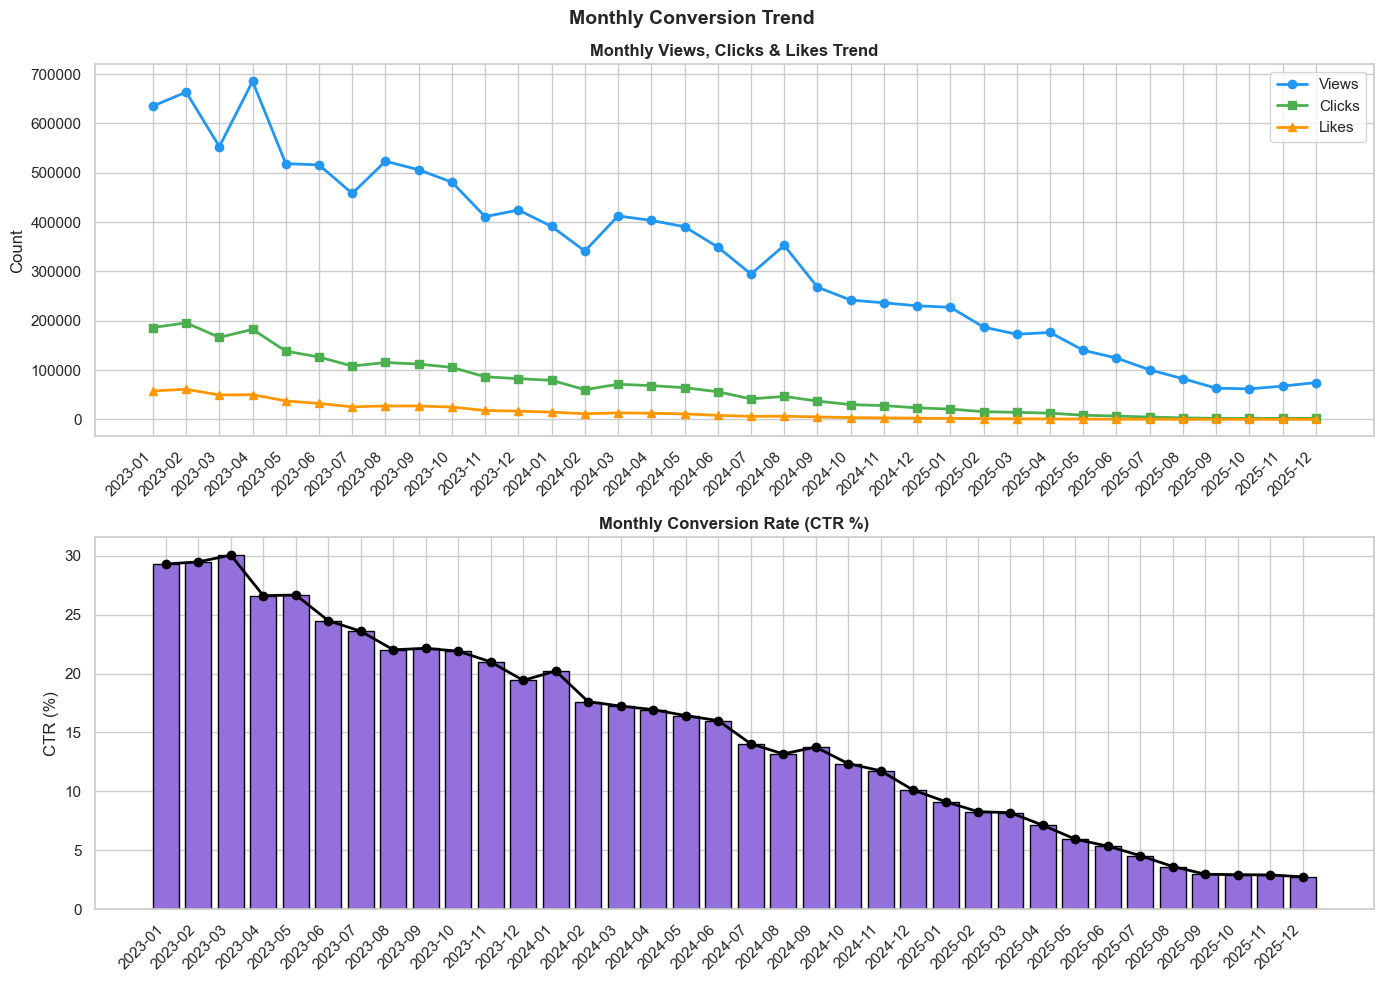

In [27]:
engagement['EngagementDate'] = pd.to_datetime(engagement['EngagementDate'])
engagement['Month'] = engagement['EngagementDate'].dt.to_period('M')

monthly = (engagement.groupby('Month')
           .agg(Views=('Views','sum'), Clicks=('Clicks','sum'), Likes=('Likes','sum'))
           .reset_index())
monthly['Month_str']   = monthly['Month'].astype(str)
monthly['Conv_Rate_%'] = (monthly['Clicks'] / monthly['Views'] * 100).round(2)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for col, color, marker, label in zip(
    ['Views','Clicks','Likes'],
    ['#2196F3','#4CAF50','#FF9800'],
    ['o','s','^'],
    ['Views','Clicks','Likes']
):
    axes[0].plot(monthly['Month_str'], monthly[col], marker=marker,
                 linewidth=2, color=color, label=label)
axes[0].set_title('Monthly Views, Clicks & Likes Trend', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].set_xticklabels(monthly['Month_str'], rotation=45, ha='right')

axes[1].bar(monthly['Month_str'], monthly['Conv_Rate_%'],
            color='mediumpurple', edgecolor='black')
axes[1].plot(monthly['Month_str'], monthly['Conv_Rate_%'],
             color='black', linewidth=2, marker='o')
axes[1].set_title('Monthly Conversion Rate (CTR %)', fontweight='bold')
axes[1].set_ylabel('CTR (%)')
axes[1].set_xticklabels(monthly['Month_str'], rotation=45, ha='right')

plt.suptitle('Monthly Conversion Trend', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Q27. Har campaign ka CTR (Click Through Rate) calculate karein

   Campaign  Total_Views  Total_Clicks  CTR_%
Campaign 16       574623        123208  21.44
Campaign 18       567727        119826  21.11
 Campaign 4       552310        114733  20.77
Campaign 13       670027        139068  20.76
Campaign 20       597771        121701  20.36
 Campaign 5       566766        114533  20.21
Campaign 14       576048        115233  20.00
 Campaign 9       563777        111544  19.79
 Campaign 8       589164        116030  19.69
Campaign 15       735203        144703  19.68
 Campaign 3       562001        110015  19.58
 Campaign 6       554979        108197  19.50
 Campaign 7       633416        122370  19.32
 Campaign 2       565111        108337  19.17
Campaign 10       518952         98370  18.96
Campaign 17       627317        118637  18.91
Campaign 11       575805        107302  18.64
Campaign 19       673675        125173  18.58
Campaign 12       563147         97224  17.26
 Campaign 1       496751         85757  17.26


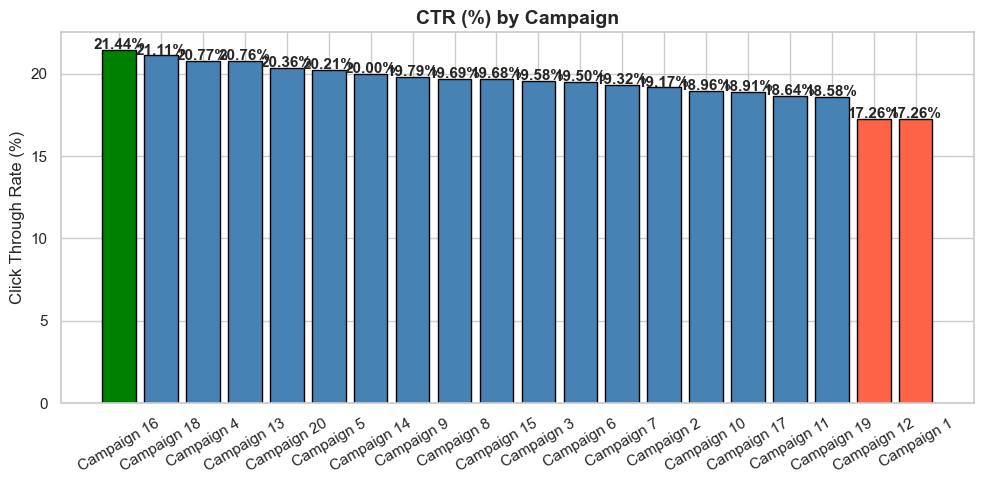

In [28]:
camp = (engagement.groupby('CompaignID')
        .agg(Total_Views=('Views','sum'),
             Total_Clicks=('Clicks','sum'),
             Total_Likes=('Likes','sum'))
        .reset_index())
camp['CTR_%'] = (camp['Total_Clicks'] / camp['Total_Views'] * 100).round(2)
camp['Campaign'] = 'Campaign ' + camp['CompaignID'].astype(str)
camp = camp.sort_values('CTR_%', ascending=False)
print(camp[['Campaign','Total_Views','Total_Clicks','CTR_%']].to_string(index=False))

max_ctr = camp['CTR_%'].max()
min_ctr = camp['CTR_%'].min()
bar_colors = ['green' if v==max_ctr else 'tomato' if v==min_ctr else 'steelblue'
              for v in camp['CTR_%']]

plt.figure(figsize=(10, 5))
bars = plt.bar(camp['Campaign'], camp['CTR_%'], color=bar_colors, edgecolor='black')
for bar, v in zip(bars, camp['CTR_%']):
    plt.text(bar.get_x()+bar.get_width()/2, v+0.05, f'{v:.2f}%',
             ha='center', fontweight='bold', fontsize=11)
plt.title('CTR (%) by Campaign', fontsize=14, fontweight='bold')
plt.ylabel('Click Through Rate (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Q28. Top performing aur lowest performing campaigns identify karein

Top Performing Campaign    : Campaign 16 | CTR: 21.44%
Lowest Performing Campaign : Campaign 1 | CTR: 17.26%

   Campaign  Total_Views  Total_Clicks  Total_Likes  CTR_%
Campaign 16       574623        123208        26757  21.44
Campaign 18       567727        119826        28386  21.11
 Campaign 4       552310        114733        26913  20.77
Campaign 13       670027        139068        33083  20.76
Campaign 20       597771        121701        29884  20.36
 Campaign 5       566766        114533        25381  20.21
Campaign 14       576048        115233        27334  20.00
 Campaign 9       563777        111544        25578  19.79
 Campaign 8       589164        116030        28239  19.69
Campaign 15       735203        144703        36464  19.68
 Campaign 3       562001        110015        26043  19.58
 Campaign 6       554979        108197        24430  19.50
 Campaign 7       633416        122370        29400  19.32
 Campaign 2       565111        108337        26628  19.17
Campa

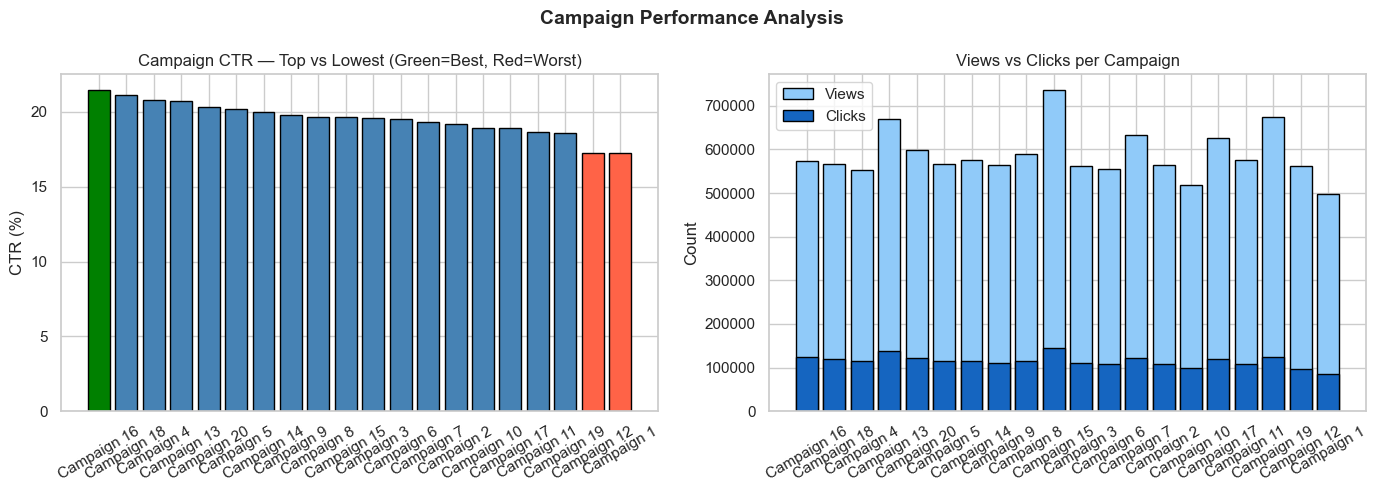

In [29]:
top_camp = camp.iloc[0]
bot_camp = camp.iloc[-1]

print(f"Top Performing Campaign    : {top_camp['Campaign']} | CTR: {top_camp['CTR_%']:.2f}%")
print(f"Lowest Performing Campaign : {bot_camp['Campaign']} | CTR: {bot_camp['CTR_%']:.2f}%")
print()
print(camp[['Campaign','Total_Views','Total_Clicks','Total_Likes','CTR_%']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_colors = ['green' if v==camp['CTR_%'].max() else 'tomato' if v==camp['CTR_%'].min() else 'steelblue'
              for v in camp['CTR_%']]
axes[0].bar(camp['Campaign'], camp['CTR_%'], color=bar_colors, edgecolor='black')
axes[0].set_title('Campaign CTR — Top vs Lowest (Green=Best, Red=Worst)')
axes[0].set_ylabel('CTR (%)')
axes[0].set_xticklabels(camp['Campaign'], rotation=30)

axes[1].bar(camp['Campaign'], camp['Total_Views'],
            color='#90CAF9', edgecolor='black', label='Views')
axes[1].bar(camp['Campaign'], camp['Total_Clicks'],
            color='#1565C0', edgecolor='black', label='Clicks')
axes[1].set_title('Views vs Clicks per Campaign')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(camp['Campaign'], rotation=30)
axes[1].legend()

plt.suptitle('Campaign Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---## Combined Analysis

### Q29. Engagement aur ratings ke darmiyan relationship — Scatter Plot + Correlation

Correlation | Rating vs Views          : 0.019
Correlation | Rating vs Clicks         : -0.028
Correlation | Rating vs Engagement Rate: -0.146


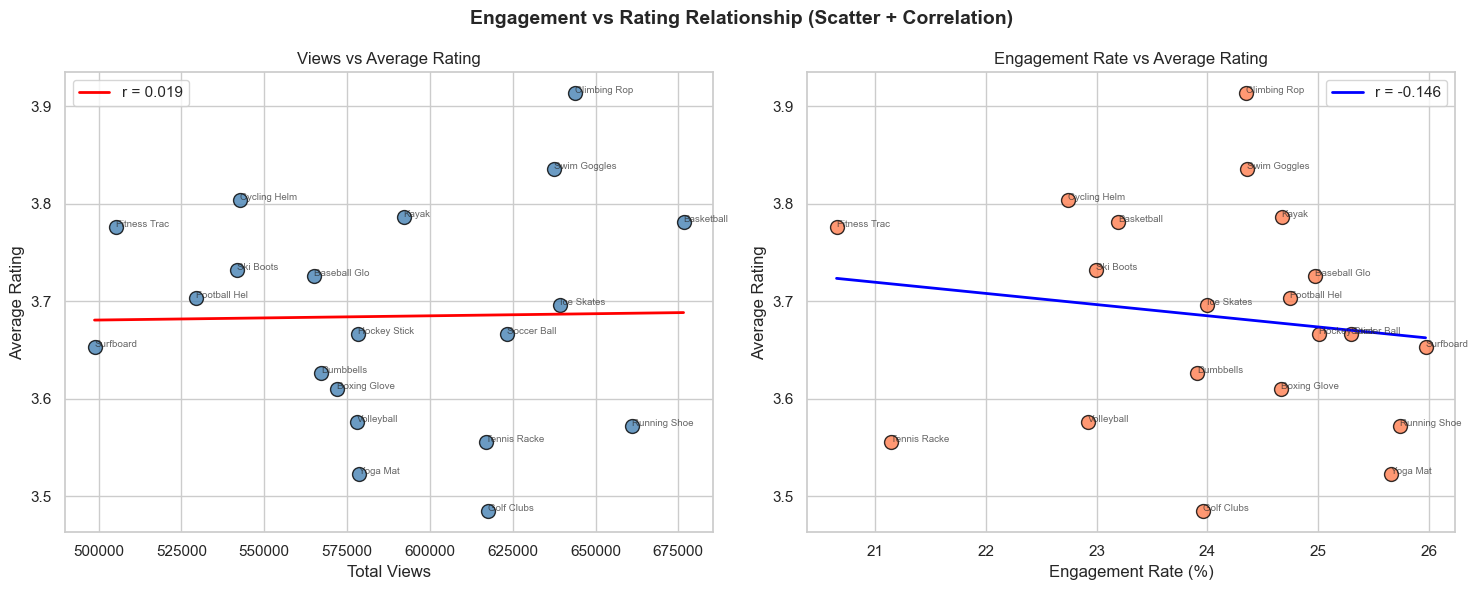


Insight: Positive correlation = zyada engaged products better rated bhi hain. Engagement badhana rating improvement ka zariya hai.


In [30]:
# Product-level: avg rating vs total engagement metrics
prod_rating_agg = reviews_full.groupby('ProductID')['Rating'].mean().reset_index()
prod_rating_agg.columns = ['ProductID','Avg_Rating']

merged_pe = (prod_rating_agg
             .merge(prod_eng[['ProductName','Total_Views','Total_Clicks','Total_Likes','Engagement_Rate']],
                    left_index=False, right_index=False, how='left',
                    left_on=prod_rating_agg.index, right_on=prod_eng.index)
             .dropna())

# Use product name join instead
prod_eng2 = prod_eng.merge(products[['ProductID','ProductName']], on='ProductName', how='left')
merged2   = prod_rating_agg.merge(prod_eng2[['ProductID','Total_Views','Total_Clicks','Total_Likes','Engagement_Rate']],
                                   on='ProductID', how='inner')
merged2   = merged2.merge(products[['ProductID','ProductName']], on='ProductID', how='left')

corr_v  = merged2['Avg_Rating'].corr(merged2['Total_Views'])
corr_c  = merged2['Avg_Rating'].corr(merged2['Total_Clicks'])
corr_er = merged2['Avg_Rating'].corr(merged2['Engagement_Rate'])

print(f"Correlation | Rating vs Views          : {corr_v:.3f}")
print(f"Correlation | Rating vs Clicks         : {corr_c:.3f}")
print(f"Correlation | Rating vs Engagement Rate: {corr_er:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Views vs Rating
axes[0].scatter(merged2['Total_Views'], merged2['Avg_Rating'],
                color='steelblue', s=100, edgecolor='black', alpha=0.8)
for _, row in merged2.iterrows():
    axes[0].annotate(row['ProductName'][:12], (row['Total_Views'], row['Avg_Rating']),
                     fontsize=7, alpha=0.7)
m, b = np.polyfit(merged2['Total_Views'], merged2['Avg_Rating'], 1)
xl = np.linspace(merged2['Total_Views'].min(), merged2['Total_Views'].max(), 100)
axes[0].plot(xl, m*xl+b, color='red', linewidth=2, label=f'r = {corr_v:.3f}')
axes[0].set_title('Views vs Average Rating')
axes[0].set_xlabel('Total Views'); axes[0].set_ylabel('Average Rating')
axes[0].legend()

# Engagement Rate vs Rating
axes[1].scatter(merged2['Engagement_Rate'], merged2['Avg_Rating'],
                color='coral', s=100, edgecolor='black', alpha=0.8)
for _, row in merged2.iterrows():
    axes[1].annotate(row['ProductName'][:12], (row['Engagement_Rate'], row['Avg_Rating']),
                     fontsize=7, alpha=0.7)
m2, b2 = np.polyfit(merged2['Engagement_Rate'], merged2['Avg_Rating'], 1)
xl2 = np.linspace(merged2['Engagement_Rate'].min(), merged2['Engagement_Rate'].max(), 100)
axes[1].plot(xl2, m2*xl2+b2, color='blue', linewidth=2, label=f'r = {corr_er:.3f}')
axes[1].set_title('Engagement Rate vs Average Rating')
axes[1].set_xlabel('Engagement Rate (%)'); axes[1].set_ylabel('Average Rating')
axes[1].legend()

plt.suptitle('Engagement vs Rating Relationship (Scatter + Correlation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInsight: Positive correlation = zyada engaged products better rated bhi hain."
      " Engagement badhana rating improvement ka zariya hai.")

### Q30. Correlation Matrix (Heatmap) — Views, Clicks, Likes, Rating, Duration, Purchase

           Views  Clicks  Likes  Rating  Duration  Purchases
Views      1.000   0.869  0.726   0.019    -0.204     -0.364
Clicks     0.869   1.000  0.908  -0.028    -0.059     -0.319
Likes      0.726   0.908  1.000  -0.146     0.013     -0.274
Rating     0.019  -0.028 -0.146   1.000     0.022      0.126
Duration  -0.204  -0.059  0.013   0.022     1.000      0.030
Purchases -0.364  -0.319 -0.274   0.126     0.030      1.000


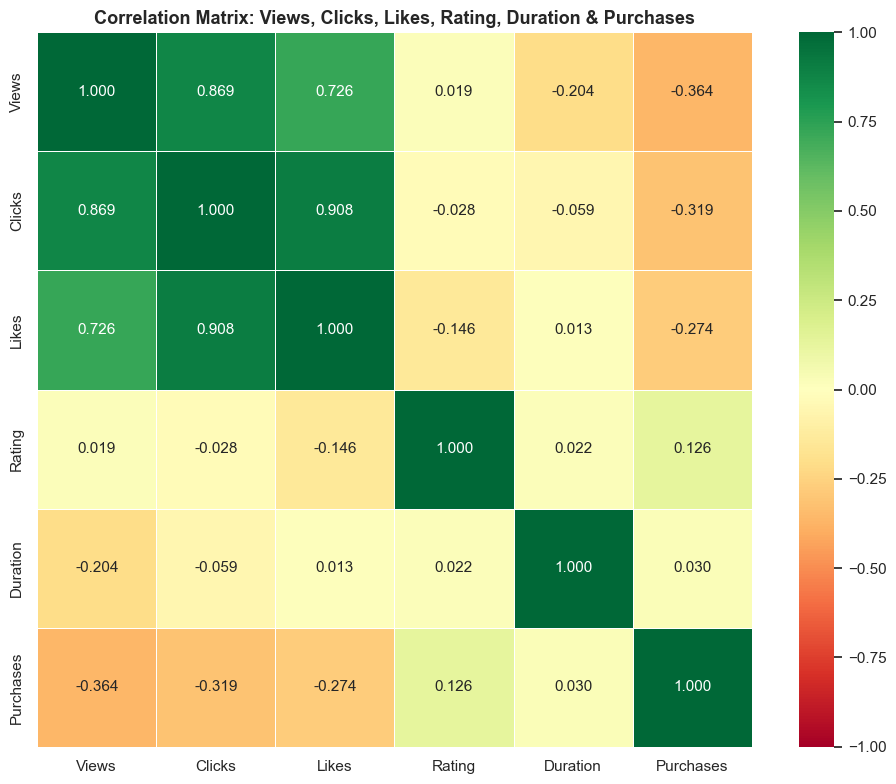


Business Insights from Correlation Matrix:

1. Views <-> Clicks:
   High positive correlation = Effective content — jo log dekhte hain wo click bhi karte hain.
   Action: Is formula ko scale karo aur zyada content produce karo.

2. Clicks <-> Purchases:
   High positive = Conversion funnel effective hai.
   Low/negative = Checkout ya pricing mein issue explore karo.

3. Rating <-> Purchases:
   Positive = Better rated products zyada bikti hain.
   Action: Product quality improve karo aur post-purchase reviews collect karo.

4. Views <-> Purchases:
   Positive = Zyada views se zyada purchases.
   Low = Audience targeting refine karo — irrelevant traffic aa raha hai.

5. Duration <-> Purchases:
   Positive = Jo customers zyada time spend karte hain wo purchase karte hain.
   Action: Product pages par engaging content add karo (videos, detailed descriptions).

6. Likes <-> Rating:
   Positive = Liked products better rated bhi hain.
   Action: Liked products ko social media par amplify ka

In [31]:
# Build product-level unified table
prod_journey_agg = (journey_full.groupby('ProductID')
                    .agg(Purchases=('Action', lambda x: (x=='Purchase').sum()),
                         Avg_Duration=('Duration','mean'))
                    .reset_index())

unified = (products[['ProductID','Price']]
           .merge(prod_eng2[['ProductID','Total_Views','Total_Clicks','Total_Likes']], on='ProductID', how='left')
           .merge(prod_rating_agg.rename(columns={'Avg_Rating':'Rating'}), on='ProductID', how='left')
           .merge(prod_journey_agg[['ProductID','Purchases','Avg_Duration']], on='ProductID', how='left')
           .dropna())

unified = unified.rename(columns={
    'Total_Views':'Views', 'Total_Clicks':'Clicks',
    'Total_Likes':'Likes', 'Avg_Duration':'Duration'
})

corr_cols = ['Views','Clicks','Likes','Rating','Duration','Purchases']
corr_matrix = unified[corr_cols].corr()
print(corr_matrix.round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, annot_kws={'size':11}, vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix: Views, Clicks, Likes, Rating, Duration & Purchases',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Business Insights from Correlation Matrix:
==========================================

1. Views <-> Clicks:
   High positive correlation = Effective content — jo log dekhte hain wo click bhi karte hain.
   Action: Is formula ko scale karo aur zyada content produce karo.

2. Clicks <-> Purchases:
   High positive = Conversion funnel effective hai.
   Low/negative = Checkout ya pricing mein issue explore karo.

3. Rating <-> Purchases:
   Positive = Better rated products zyada bikti hain.
   Action: Product quality improve karo aur post-purchase reviews collect karo.

4. Views <-> Purchases:
   Positive = Zyada views se zyada purchases.
   Low = Audience targeting refine karo — irrelevant traffic aa raha hai.

5. Duration <-> Purchases:
   Positive = Jo customers zyada time spend karte hain wo purchase karte hain.
   Action: Product pages par engaging content add karo (videos, detailed descriptions).

6. Likes <-> Rating:
   Positive = Liked products better rated bhi hain.
   Action: Liked products ko social media par amplify karo.

Summary: Engagement → Visits → Purchases yeh core growth loop hai.
Har step optimize karo to compound revenue growth achieve ho sake.""")